In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
train_df = pd.read_csv("creditcard.csv")

prod_files = [
    "../drift_1.csv",
    "../drift_2.csv",
    "../drift_3.csv",
    "../drift_4.csv",
    "../drift_5.csv",
]
prod_dfs = [pd.read_csv(f) for f in prod_files]

FEATURES = joblib.load("feature_list.pkl")

In [3]:
print("── Summary Statistics ───────────────────────────")
stats_rows = []
for i, df in enumerate([train_df] + prod_dfs):
    row = df[FEATURES].describe().loc[["mean", "std"]].T
    row.columns = ["mean", "std"]
    row["dataset"] = "Train" if i == 0 else f"Prod {i}"
    stats_rows.append(row)

# Show mean of Amount and a few key features across datasets
key_features = ["Amount", "V14", "V10", "V12", "V4", "V17"]
print(f"\n{'Feature':<10}", end="")
labels = ["Train"] + [f"Prod{i+1}" for i in range(5)]
for l in labels:
    print(f"{l:>10}", end="")
print()

for feat in key_features:
    print(f"{feat:<10}", end="")
    for df in [train_df] + prod_dfs:
        print(f"{df[feat].mean():>10.3f}", end="")
    print()

── Summary Statistics ───────────────────────────

Feature        Train     Prod1     Prod2     Prod3     Prod4     Prod5
Amount        88.350   142.655   639.868    89.966    89.452    93.527
V14            0.000    -0.007    -0.004    -0.020    -0.001    -0.062
V10            0.000    -0.014     0.022    -0.030    -0.007    -0.065
V12           -0.000    -0.008     0.002    -0.031     0.004    -0.065
V4             0.000    -0.008    -0.016     0.001     0.007     0.043
V17           -0.000     0.001     0.005    -0.038    -0.000    -0.074


In [4]:
print("\n── Fraud Rates ──────────────────────────────────")
for label, df in zip(labels, [train_df] + prod_dfs):
    rate = df["Class"].mean() * 100
    count = df["Class"].sum()
    print(f"  {label:<8}: {rate:.3f}%  ({count} fraud cases out of {len(df)})")


── Fraud Rates ──────────────────────────────────
  Train   : 0.173%  (492 fraud cases out of 284807)
  Prod1   : 0.193%  (29 fraud cases out of 15000)
  Prod2   : 0.160%  (24 fraud cases out of 15000)
  Prod3   : 0.522%  (94 fraud cases out of 18000)
  Prod4   : 0.167%  (25 fraud cases out of 15000)
  Prod5   : 2.000%  (300 fraud cases out of 15000)


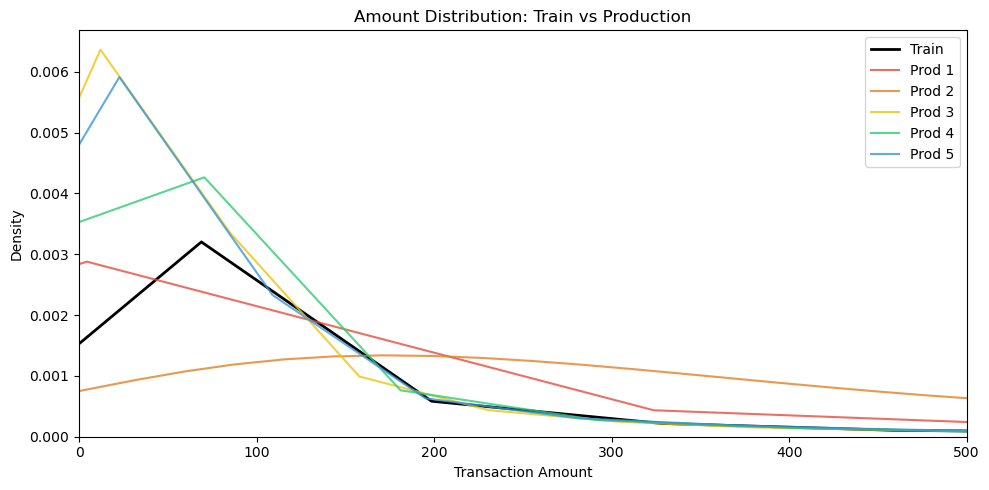

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(train_df["Amount"], ax=ax, label="Train", linewidth=2, color="black")
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db"]
for i, df in enumerate(prod_dfs):
    sns.kdeplot(df["Amount"], ax=ax, label=f"Prod {i+1}",
                linewidth=1.5, color=colors[i], alpha=0.8)

ax.set_xlim(0, 500)   # zoom in — extreme outliers distort the plot
ax.set_title("Amount Distribution: Train vs Production")
ax.set_xlabel("Transaction Amount")
ax.legend()
plt.tight_layout()
plt.show()

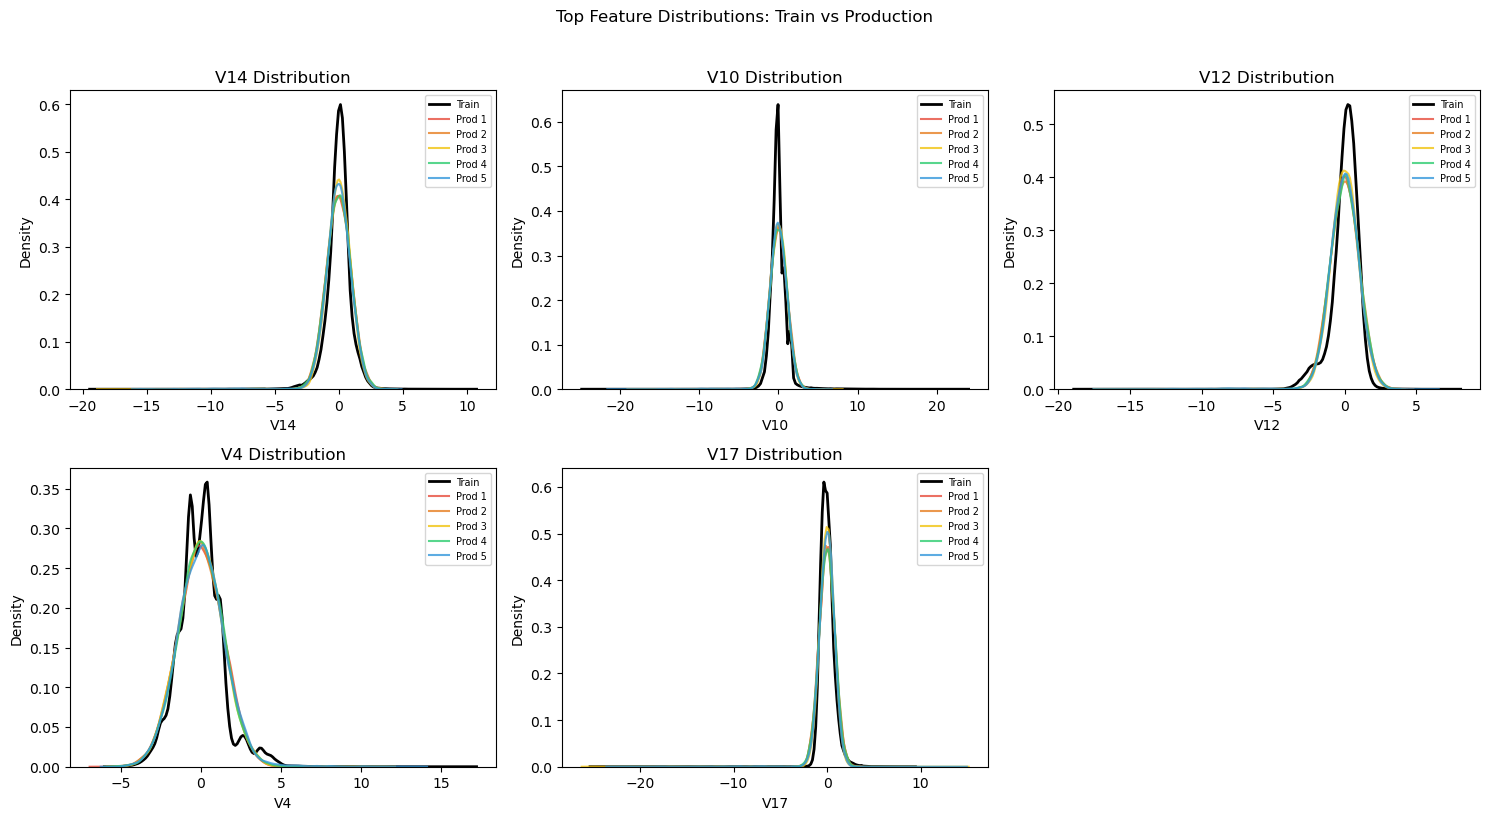

In [6]:
top_features = ["V14", "V10", "V12", "V4", "V17"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    ax = axes[idx]
    sns.kdeplot(train_df[feat], ax=ax, label="Train",
                linewidth=2, color="black")
    for i, df in enumerate(prod_dfs):
        sns.kdeplot(df[feat], ax=ax, label=f"Prod {i+1}",
                    linewidth=1.5, color=colors[i], alpha=0.8)
    ax.set_title(f"{feat} Distribution")
    ax.legend(fontsize=7)

axes[-1].set_visible(False)  # hide the 6th empty subplot
plt.suptitle("Top Feature Distributions: Train vs Production", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\emikr\AppData\Local\Temp\ipykernel_5780\2034077650.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x="Dataset", y="Amount",


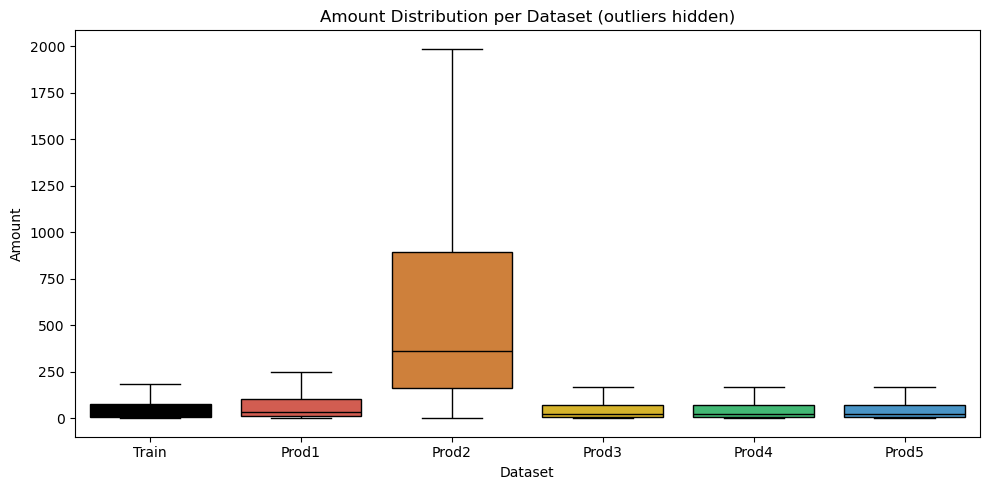


All distribution plots saved.


In [7]:
combined = []
for label, df in zip(labels, [train_df] + prod_dfs):
    tmp = df[["Amount"]].copy()
    tmp["Dataset"] = label
    combined.append(tmp)
combined_df = pd.concat(combined)

plt.figure(figsize=(10, 5))
sns.boxplot(data=combined_df, x="Dataset", y="Amount",
            palette=["black"] + colors, showfliers=False)
plt.title("Amount Distribution per Dataset (outliers hidden)")
plt.tight_layout()
plt.show()

print("\nAll distribution plots saved.")